# Biological Interpretation

**Project:** crohns-microbiome-ml &nbsp;|&nbsp; **Notebook 05** &nbsp;|&nbsp; Roadmap Week 6

The classifier separates Crohn's from healthy above chance (honest patient-level AUC ≈ 0.68,
notebook 04). This notebook asks the scientific question behind that number: **which taxa carry the
signal, and in which direction?** We use SHAP values on the Random Forest to rank taxa and, for
each, determine whether it is *enriched* or *depleted* in Crohn's disease.

In [1]:
import sys, warnings
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import microbiome as mb
from sklearn.ensemble import RandomForestClassifier

otu_meta, counts, taxa = mb.load_otu_meta()
otu_final = mb.preprocess(counts)
X, y = mb.cd_vs_nonibd(otu_final, otu_meta)

rf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1,
                            class_weight='balanced').fit(X, y)
shap_values = shap.TreeExplainer(rf).shap_values(X)[:, :, 1]   # SHAP for the CD class
print('SHAP matrix:', shap_values.shape)

SHAP matrix: (132, 179)


## Top-20 taxa by SHAP importance

The beeswarm shows each taxon's effect on the CD prediction. Each dot is a sample; colour is the
taxon's CLR abundance (red = high, blue = low); horizontal position is its push toward CD (right)
or healthy (left).

Saved figures/shap_beeswarm_top20.png


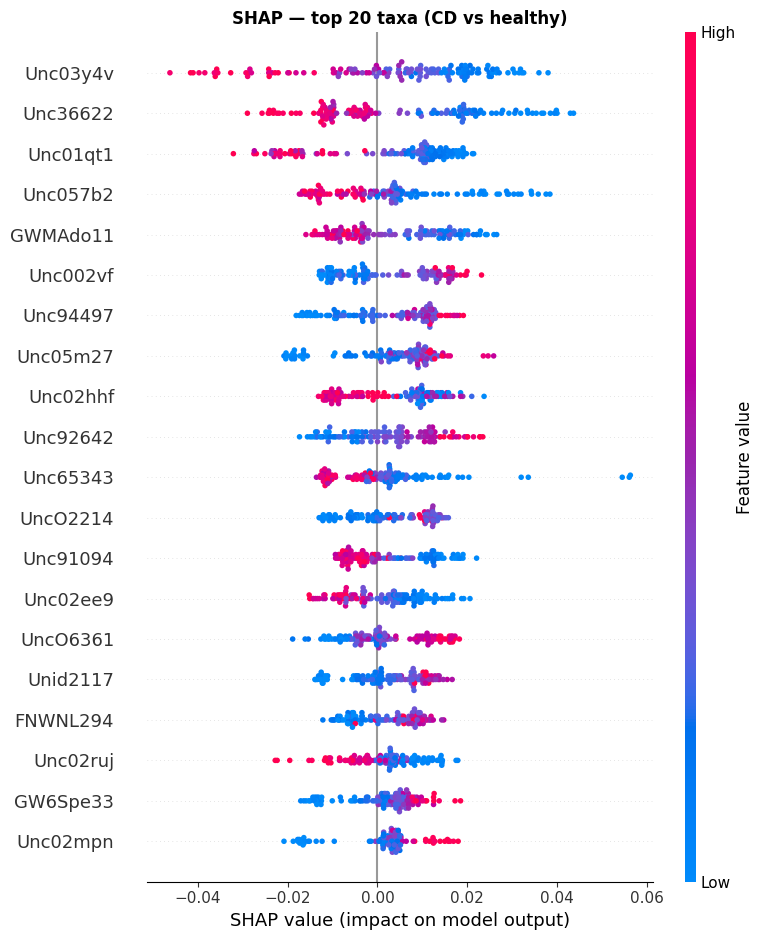

In [2]:
shap.summary_plot(shap_values, X, plot_type='dot', max_display=20, show=False)
plt.title('SHAP — top 20 taxa (CD vs healthy)', fontweight='bold')
plt.tight_layout(); plt.savefig('../figures/shap_beeswarm_top20.png', dpi=150, bbox_inches='tight')
print('Saved figures/shap_beeswarm_top20.png'); plt.show()

## Annotation table: rank, importance, and direction of effect

For each top taxon we record its mean |SHAP| (importance) and its **direction**: the difference in
mean CLR abundance between CD and healthy samples. Negative = *depleted* in CD; positive =
*enriched* in CD. The "high abundance pushes toward" column reads the beeswarm quantitatively as
the sign of the correlation between abundance and SHAP value.

In [3]:
mean_abs = pd.Series(np.abs(shap_values).mean(0), index=X.columns)
top20 = mean_abs.sort_values(ascending=False).head(20).index

rows = []
for t in top20:
    j = list(X.columns).index(t)
    push = 'CD' if np.corrcoef(X[t], shap_values[:, j])[0, 1] > 0 else 'healthy'
    d_clr = X.loc[y == 1, t].mean() - X.loc[y == 0, t].mean()
    rows.append({'taxon': t, 'mean|SHAP|': round(mean_abs[t], 4),
                 'dCLR (CD-healthy)': round(d_clr, 2),
                 'direction': 'enriched in CD' if d_clr > 0 else 'depleted in CD',
                 'high abundance pushes->': push})
annot = pd.DataFrame(rows)
annot.index = range(1, 21); annot.index.name = 'rank'
annot

,taxon,mean|SHAP|,dCLR (CD-healthy),direction,high abundance pushes->
rank,,,,,
1,Unc03y4v,0.0168,-1.41,depleted in CD,healthy
2,Unc36622,0.0158,-1.92,depleted in CD,healthy
3,Unc01qt1,0.0135,-1.46,depleted in CD,healthy
4,Unc057b2,0.0108,-1.46,depleted in CD,healthy
5,GWMAdo11,0.0102,-0.99,depleted in CD,healthy
6,Unc002vf,0.0097,0.91,enriched in CD,CD
7,Unc94497,0.0096,0.87,enriched in CD,CD
8,Unc05m27,0.0094,0.75,enriched in CD,CD
9,Unc02hhf,0.0093,-0.73,depleted in CD,healthy


Top 20: 10 depleted in CD, 10 enriched in CD
Top 5 directions: ['depleted', 'depleted', 'depleted', 'depleted', 'depleted']
Summed |SHAP| — depleted: 0.106  enriched: 0.079
Saved figures/taxa_direction.png


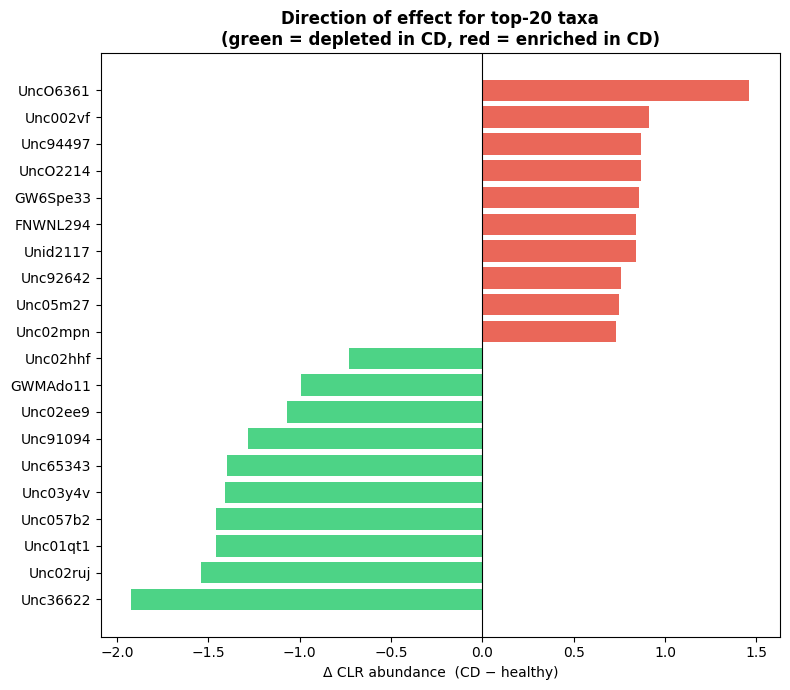

In [4]:
# Where does the importance concentrate — depleted or enriched taxa?
depleted = annot[annot['direction'].str.startswith('depleted')]
enriched = annot[annot['direction'].str.startswith('enriched')]
print(f"Top 20: {len(depleted)} depleted in CD, {len(enriched)} enriched in CD")
print(f"Top 5 directions: {list(annot['direction'].head(5).str.split().str[0])}")
print(f"Summed |SHAP| — depleted: {depleted['mean|SHAP|'].sum():.3f}  "
      f"enriched: {enriched['mean|SHAP|'].sum():.3f}")

# Direction-of-effect chart
order = annot.sort_values('dCLR (CD-healthy)')
colors = ['#2ecc71' if v < 0 else '#e74c3c' for v in order['dCLR (CD-healthy)']]
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(order['taxon'], order['dCLR (CD-healthy)'], color=colors, alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Δ CLR abundance  (CD − healthy)')
ax.set_title('Direction of effect for top-20 taxa\n(green = depleted in CD, red = enriched in CD)',
             fontweight='bold')
plt.tight_layout(); plt.savefig('../figures/taxa_direction.png', dpi=150)
print('Saved figures/taxa_direction.png'); plt.show()

## A naming limitation — and what we can still say

**We cannot attach confident species names to these taxa.** The HMP2 16S table labels taxa with
short Greengenes-derived OTU ids (`Unc03y4v`, `GWMAdo11`, …); resolving them to a
kingdom→…→species lineage requires joining to the external Greengenes reference taxonomy, which is
not part of the downloaded file. Compounding this, the great majority of the discriminative taxa
carry the `Unc` prefix — **uncultured** organisms known only from sequence, which by definition
have no validated species name. (This is itself representative of gut-microbiome reality: much of
the community has never been cultured.)

So we interpret at the level the data supports — **importance and direction** — rather than
inventing Linnaean labels. That is still enough for a real biological reading.

## Headline result and biological narrative

**One sentence:** *Crohn's disease is marked less by a single culprit organism than by the
depletion of a set of health-associated gut commensals — and the strongest features our model uses
are exactly those depletions.*

The evidence:

- The **five most important taxa are all depleted in CD** — high abundance of each pushes the
  prediction toward *healthy*. The model's primary lever is the **absence** of normally-present
  organisms, not the presence of a pathogen.
- This mirrors the community-level finding from notebooks 01 and 04: Crohn's samples have
  significantly **lower Shannon diversity** (CD 2.44 vs healthy 2.78, Mann-Whitney p = 0.007). The
  per-taxon SHAP picture is the mechanism behind that diversity loss — specific commensals dropping
  out.
- A second, weaker set of taxa is **enriched in CD**, consistent with opportunists expanding into
  the niche left by the depleted commensals (the "pathobiont bloom" pattern).

**Connection to known biology (with a caveat).** The signature of Crohn's as *loss of beneficial
commensals* — classically the butyrate-producers *Faecalibacterium prausnitzii* and *Roseburia* —
is one of the most reproducible findings in IBD microbiome research, and our depletion-dominated
result is fully consistent with it **at the pattern level**. We stop short of claiming the model
rediscovered those specific species, because the OTU ids can't be resolved to confirm identity.
The honest statement is: *the model independently recovered the well-established depletion signature
of Crohn's, without us telling it any biology.*

**Performance in context.** Read alongside notebook 04, the story is coherent: a single 16S
snapshot carries a real but modest signal (patient-level AUC ≈ 0.68), driven by a broad community
shift rather than a sharp biomarker. That is biologically sensible — IBD is driven by host genetics
and immune dysregulation that the microbiome reflects partially. A microbiome classifier is a
useful **correlate**, not a stand-alone diagnostic, and this project's value is in showing that
distinction honestly.